In [15]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

REPORTS_DIR = "../reports/"
VISUALS_DIR = "../visuals/"

os.makedirs(VISUALS_DIR, exist_ok=True)

print("Libraries loaded")


Libraries loaded


In [16]:
# Loading report data
df_inventors = pd.read_csv(REPORTS_DIR + "top_inventors.csv")
df_companies = pd.read_csv(REPORTS_DIR + "top_companies.csv")
df_countries = pd.read_csv(REPORTS_DIR + "country_trends.csv")
df_years = pd.read_csv(REPORTS_DIR + "patents_per_year.csv")

print("All data loaded")
print(f"Inventors: {len(df_inventors)} rows")
print(f"Companies: {len(df_companies)} rows")
print(f"Countries: {len(df_countries)} rows")
print(f"Years:     {len(df_years)} rows")

All data loaded
Inventors: 20 rows
Companies: 20 rows
Countries: 20 rows
Years:     1 rows


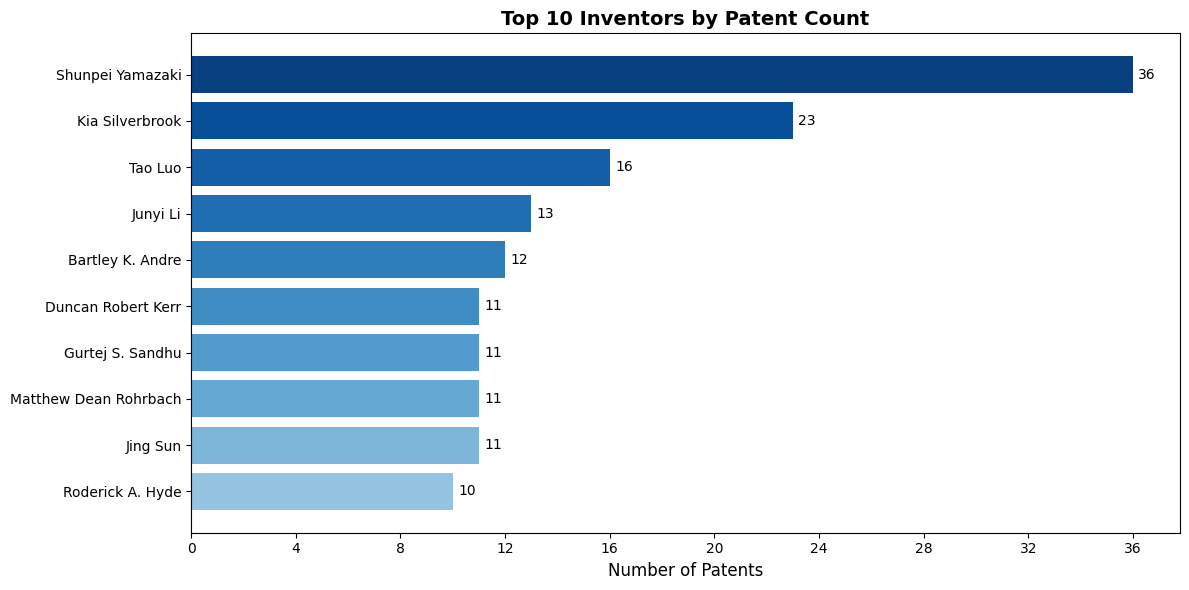

Chart saved: top_inventors.png


In [17]:
# Chart 1: Top 10 Inventors
fig, ax = plt.subplots(figsize=(12, 6))

top10_inv = df_inventors.head(10).sort_values('patent_count')
colors = plt.cm.Blues([0.4 + 0.06 * i for i in range(len(top10_inv))])

ax.barh(top10_inv['full_name'], top10_inv['patent_count'], color=colors)
ax.set_xlabel("Number of Patents", fontsize=12)
ax.set_title("Top 10 Inventors by Patent Count", fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for i, v in enumerate(top10_inv['patent_count']):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig(VISUALS_DIR + "top_inventors.png", dpi=150)
plt.show()
print("Chart saved: top_inventors.png")

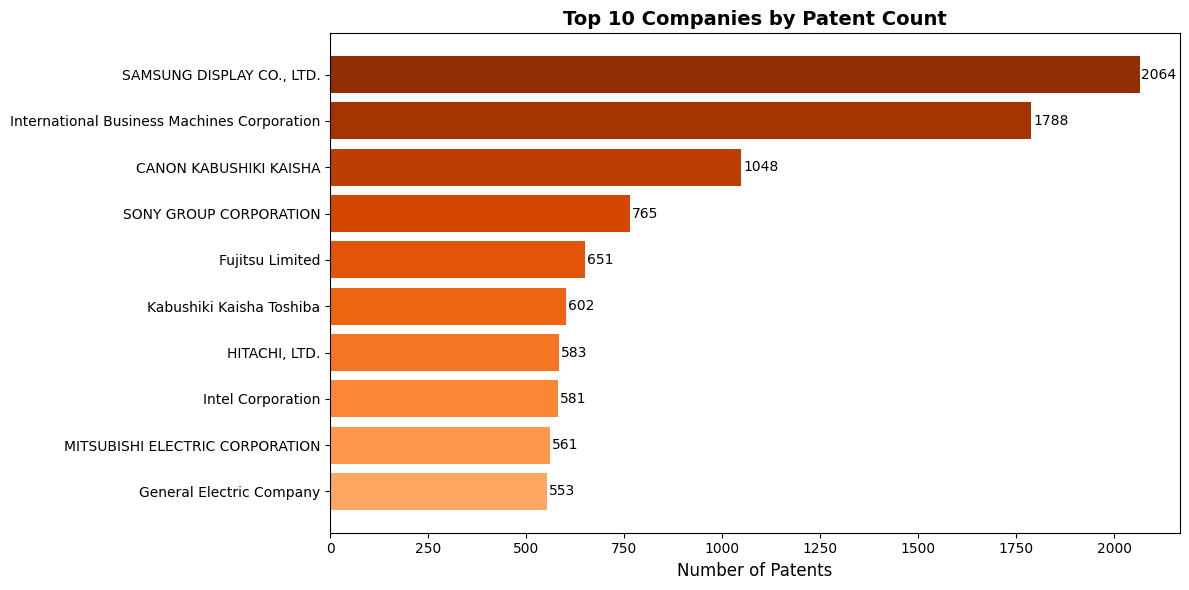

Chart saved: top_companies.png


In [18]:
# Chart 2: Top 10 companies
fig, ax = plt.subplots(figsize=(12, 6))

top10_comp = df_companies.head(10).sort_values('patent_count')
colors = plt.cm.Oranges([0.4 + 0.06 * i for i in range(len(top10_comp))])

ax.barh(top10_comp['name'], top10_comp['patent_count'], color=colors)
ax.set_xlabel("Number of Patents", fontsize=12)
ax.set_title("Top 10 Companies by Patent Count", fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for i, v in enumerate(top10_comp['patent_count']):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig(VISUALS_DIR + "top_companies.png", dpi=150)
plt.show()
print("Chart saved: top_companies.png")

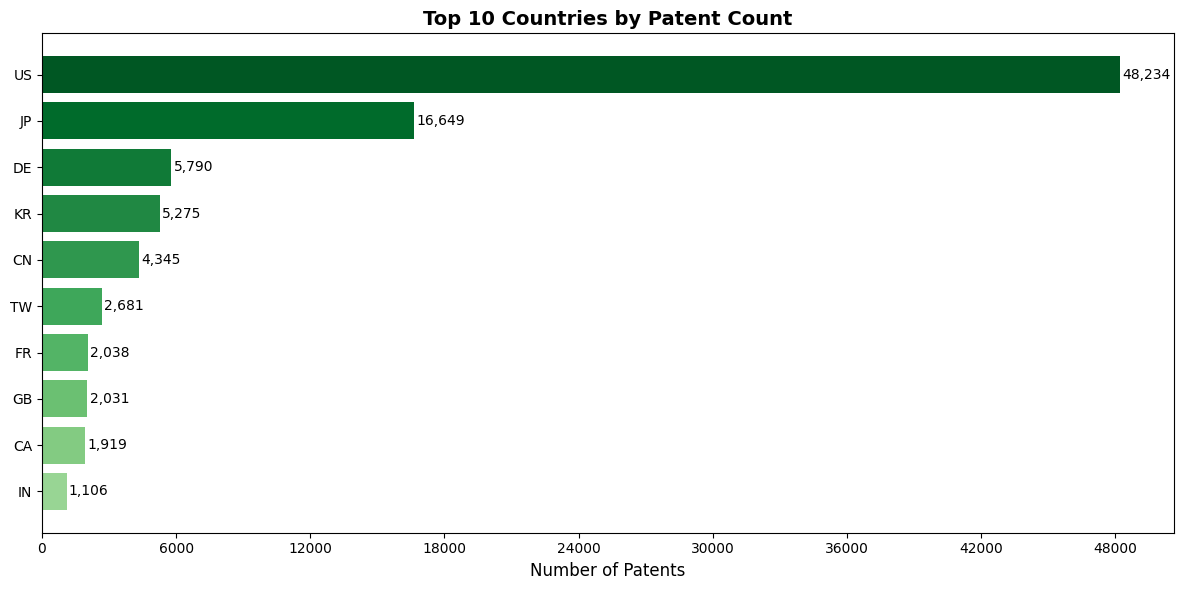

Chart saved: top_countries.png


In [19]:
#Chart 3: Top 10 countries
fig, ax = plt.subplots(figsize=(12, 6))

top10_countries = df_countries.head(10).sort_values('patent_count')
colors = plt.cm.Greens([0.4 + 0.06 * i for i in range(len(top10_countries))])

ax.barh(top10_countries['country'], top10_countries['patent_count'], color=colors)
ax.set_xlabel("Number of Patents", fontsize=12)
ax.set_title("Top 10 Countries by Patent Count", fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for i, v in enumerate(top10_countries['patent_count']):
    ax.text(v + 100, i, f"{v:,}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig(VISUALS_DIR + "top_countries.png", dpi=150)
plt.show()
print("Chart saved: top_countries.png")

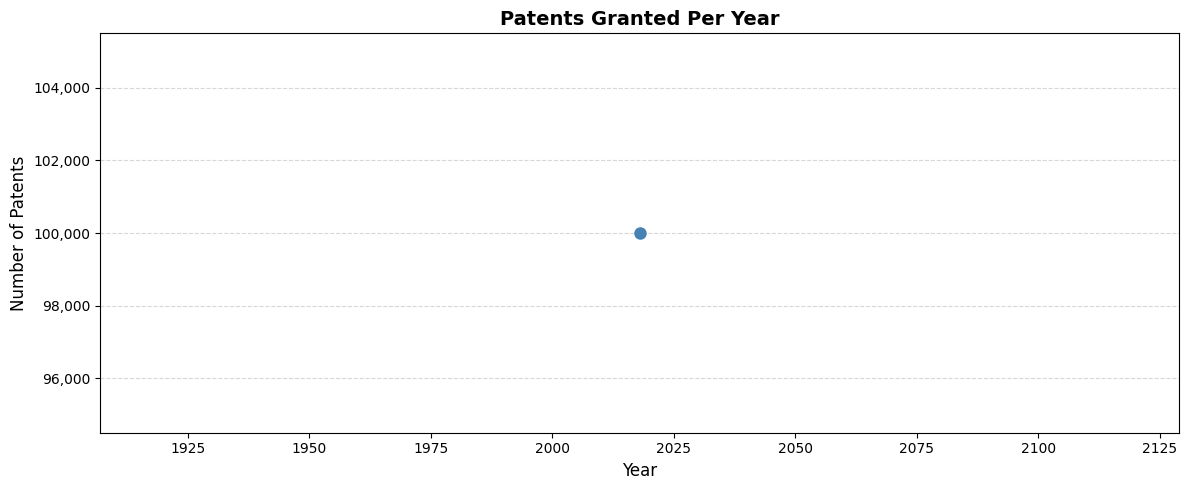

Chart saved: patents_per_year.png


In [20]:
# Chart 4: Patents per year
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_years['year'], df_years['patent_count'],
        marker='o', color='steelblue', linewidth=2, markersize=8)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Patents", fontsize=12)
ax.set_title("Patents Granted Per Year", fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(VISUALS_DIR + "patents_per_year.png", dpi=150)
plt.show()
print("Chart saved: patents_per_year.png")

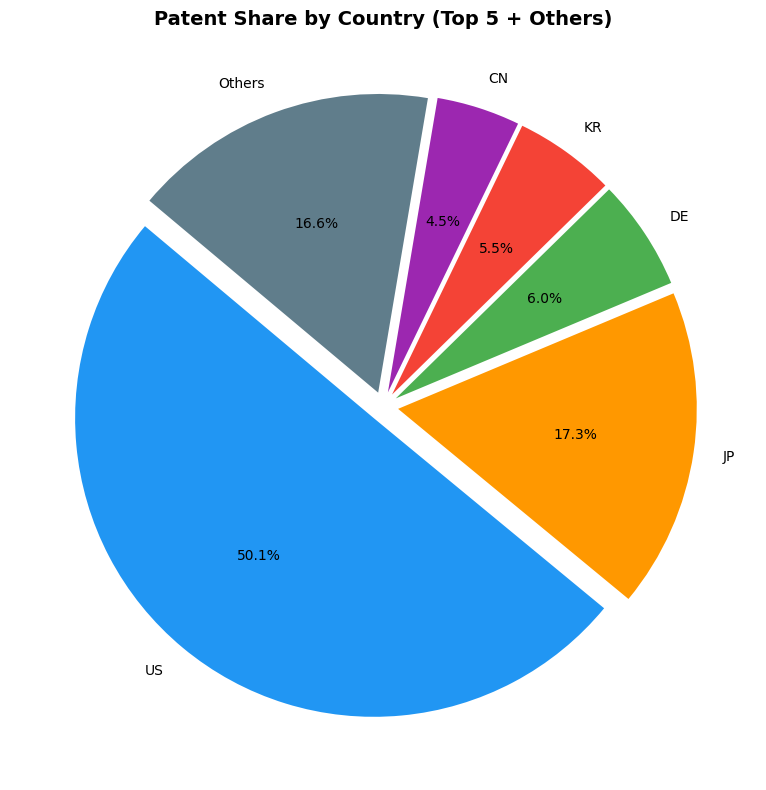

Chart saved: country_share.png


In [21]:
# Chart 5: Country share pie chart
fig, ax = plt.subplots(figsize=(10, 8))

top5 = df_countries.head(5).copy()
other = pd.DataFrame([{
    'country': 'Others',
    'patent_count': df_countries.iloc[5:]['patent_count'].sum()
}])
pie_data = pd.concat([top5, other], ignore_index=True)

colors = ['#2196F3','#FF9800','#4CAF50','#F44336','#9C27B0','#607D8B']
explode = [0.05] * len(pie_data)

ax.pie(
    pie_data['patent_count'],
    labels=pie_data['country'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140
)

ax.set_title("Patent Share by Country (Top 5 + Others)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(VISUALS_DIR + "country_share.png", dpi=150)
plt.show()
print("Chart saved: country_share.png")

In [22]:
#Verify All Charts Saved
charts = [
    "top_inventors.png",
    "top_companies.png",
    "top_countries.png",
    "patents_per_year.png",
    "country_share.png"
]

print("VISUALS CHECK")
print("=" * 40)
for c in charts:
    path = VISUALS_DIR + c
    exists = os.path.exists(path)
    print(f"{c}: {'EXISTS' if exists else 'MISSING'}")

VISUALS CHECK
top_inventors.png: EXISTS
top_companies.png: EXISTS
top_countries.png: EXISTS
patents_per_year.png: EXISTS
country_share.png: EXISTS


In [23]:
# Building Streamlit Dashboard File
dashboard_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

st.set_page_config(page_title="Patent Intelligence Dashboard", layout="wide")

REPORTS_DIR = "reports/"
VISUALS_DIR = "visuals/"

st.title("Global Patent Intelligence Dashboard")
st.markdown("Data source: PatentsView - USPTO Granted Patents")

with open(REPORTS_DIR + "report.json") as f:
    report = json.load(f)

summary = report["summary"]

col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Patents",   f"{summary['total_patents']:,}")
col2.metric("Total Inventors", f"{summary['total_inventors']:,}")
col3.metric("Total Companies", f"{summary['total_companies']:,}")
col4.metric("Total Countries", f"{summary['total_countries']:,}")

st.markdown("---")

col_a, col_b = st.columns(2)

with col_a:
    st.subheader("Top 10 Inventors")
    st.image(VISUALS_DIR + "top_inventors.png")

with col_b:
    st.subheader("Top 10 Companies")
    st.image(VISUALS_DIR + "top_companies.png")

st.markdown("---")

col_c, col_d = st.columns(2)

with col_c:
    st.subheader("Top 10 Countries")
    st.image(VISUALS_DIR + "top_countries.png")

with col_d:
    st.subheader("Country Share")
    st.image(VISUALS_DIR + "country_share.png")

st.markdown("---")
st.subheader("Patents Per Year")
st.image(VISUALS_DIR + "patents_per_year.png")

st.markdown("---")
st.subheader("Top 10 Inventors Table")
df_inv = pd.DataFrame(report["top_inventors"])
st.dataframe(df_inv, use_container_width=True)

st.subheader("Top 10 Companies Table")
df_comp = pd.DataFrame(report["top_companies"])
st.dataframe(df_comp, use_container_width=True)

st.subheader("Top 10 Countries Table")
df_countries = pd.DataFrame(report["top_countries"])
st.dataframe(df_countries, use_container_width=True)
'''

with open("../dashboard.py", "w") as f:
    f.write(dashboard_code)

print("dashboard.py saved in project root folder")
print("To run it, open terminal and type:")
print("streamlit run dashboard.py")

dashboard.py saved in project root folder
To run it, open terminal and type:
streamlit run dashboard.py


In [24]:

print("")
print("VISUALS SAVED:")
print("  top_inventors.png")
print("  top_companies.png")
print("  top_countries.png")
print("  patents_per_year.png")
print("  country_share.png")
print("")
print("DASHBOARD FILE SAVED:")
print("  dashboard.py")
print("")



VISUALS SAVED:
  top_inventors.png
  top_companies.png
  top_countries.png
  patents_per_year.png
  country_share.png

DASHBOARD FILE SAVED:
  dashboard.py

